In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

# Load in data

In [2]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 12.1 s, sys: 1.14 s, total: 13.2 s
Wall time: 15.4 s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


# Cell counts

In [10]:
counts = (
    df.groupby(["time", "stage", "condition", "scene"])
      .size()
      .reset_index(name="n_cells")
)

# shift stage 2 times to follow after stage 1
max_time_stage1 = counts.loc[counts["stage"] == 1, "time"].max()
counts["time_shifted"] = counts["time"] + (
    (counts["stage"] == 2) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
counts['time_hours'] = counts['time_shifted'] / 3

# Get baseline counts (time=0) for each group
baseline = (
    counts.loc[counts["time"] == 0, ["stage", "condition", "scene", "n_cells"]]
    .rename(columns={"n_cells": "baseline_cells"})
)

counts = counts.merge(baseline, on=["stage", "condition", "scene"], how="left")

counts['n_cells_rel'] = counts['n_cells'] / counts['baseline_cells']
counts['n_cells_log2'] = np.log2(counts['n_cells_rel'])
counts['n_cells_abs'] = counts['n_cells'] - counts['baseline_cells']

print(counts.shape)
counts.head()

(2040, 11)


,time,stage,condition,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,hybrid,C3,615,0,0.0,615,1.0,0.0,0
4,0,1,hybrid,C4,768,0,0.0,768,1.0,0.0,0


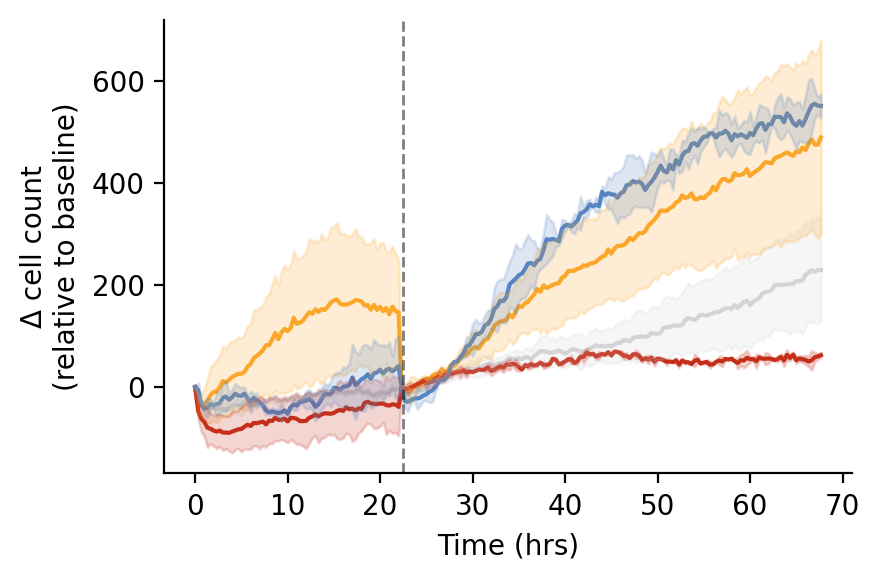

In [34]:
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(4.5, 3))


cond_palette = {
    'control': '#D3D4D8',
    'hybrid': '#FBA72A',
    'mmMYOD1': '#C52E19',
    'siPRRX1': '#5785C1',
}

# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

# summarized lineplot (mean ± 95% CI across scenes)
sns.lineplot(
    data=counts,
    x="time_hours",
    y='n_cells_abs',
    # y="n_cells_log2",
    hue="condition",
    palette=cond_palette,
    lw=1.5,
    errorbar="sd",  # mean ± 95% CI
    ax=ax,
    zorder=0,
    legend=False,
)

# stage transition line
plt.axvline(max_time_stage1/3 + 0.5, ls="--", c="k", lw=1, alpha=0.5, zorder=2)

plt.xlabel("Time (hrs)")
# plt.ylabel("Cell count (fold change)")
# plt.ylabel("Cell count")
plt.ylabel("Δ cell count\n(relative to baseline)")
# plt.ylabel("$log_2$(Δ cell count)")

sns.despine()
plt.tight_layout()
plt.show()

In [12]:
counts.head()

,time,stage,condition,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,hybrid,C3,615,0,0.0,615,1.0,0.0,0
4,0,1,hybrid,C4,768,0,0.0,768,1.0,0.0,0


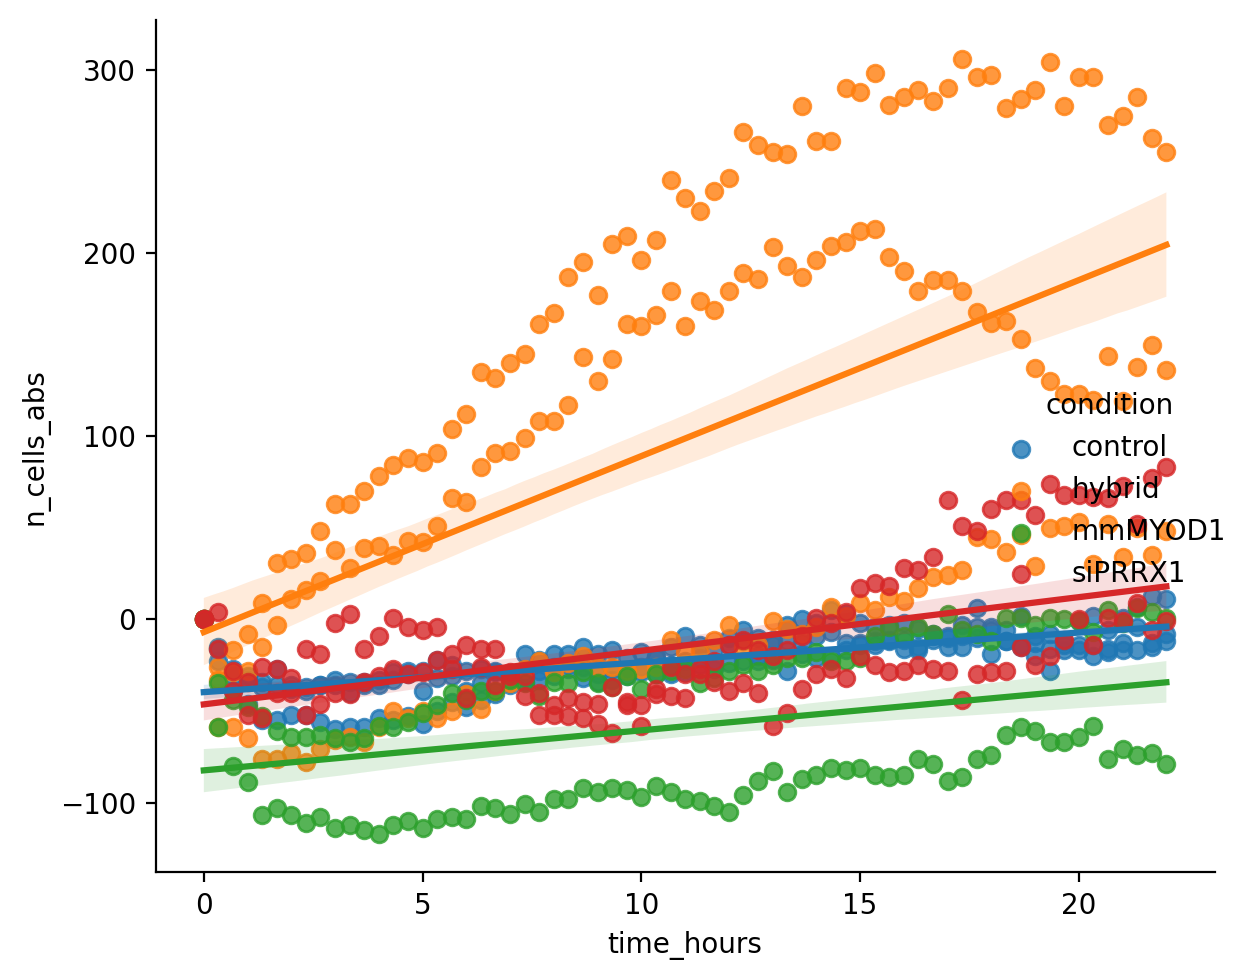

In [21]:
tmp = counts[counts['stage'] == 1].copy()

sns.lmplot(
    data=tmp,
    x='time_hours',
    y='n_cells_abs',
    hue='condition',
)

plt.tight_layout()
plt.show()

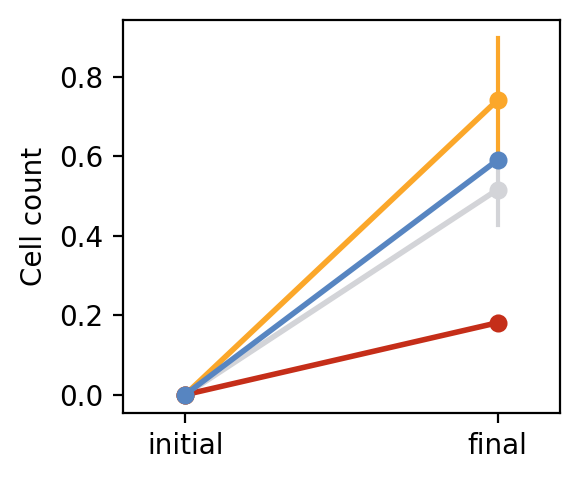

In [37]:
# get global initial and final counts per (condition, scene, stage)
cell_col = 'n_cells_log2'

endpoints = (
    counts.groupby(["condition", "scene", "stage"])
    .agg(initial=(cell_col, "first"), final=(cell_col, "last"))
    .reset_index()
)

endpoints.head()

endpoints_melt = endpoints.melt(
    id_vars=["condition", "scene", "stage"],
    value_vars=["initial", "final"],
    var_name="timepoint", value_name=cell_col
)

endpoints_melt.head()

stage = 2
endpoints_melt = endpoints_melt[endpoints_melt['stage'] == stage]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (3, 2.5)

# plot points
sns.pointplot(
    data=endpoints_melt,
    x="timepoint",
    y=cell_col,
    hue="condition",
    errorbar='se',
    lw=2,
    legend=False,
    palette=cond_palette,
    markersize=5,
    err_kws={"linewidth": 1.5},#, 'color': 'k'}
)

plt.margins(x=0.2)
plt.xlabel("")
plt.ylabel("Cell count")
plt.tight_layout()
plt.show()

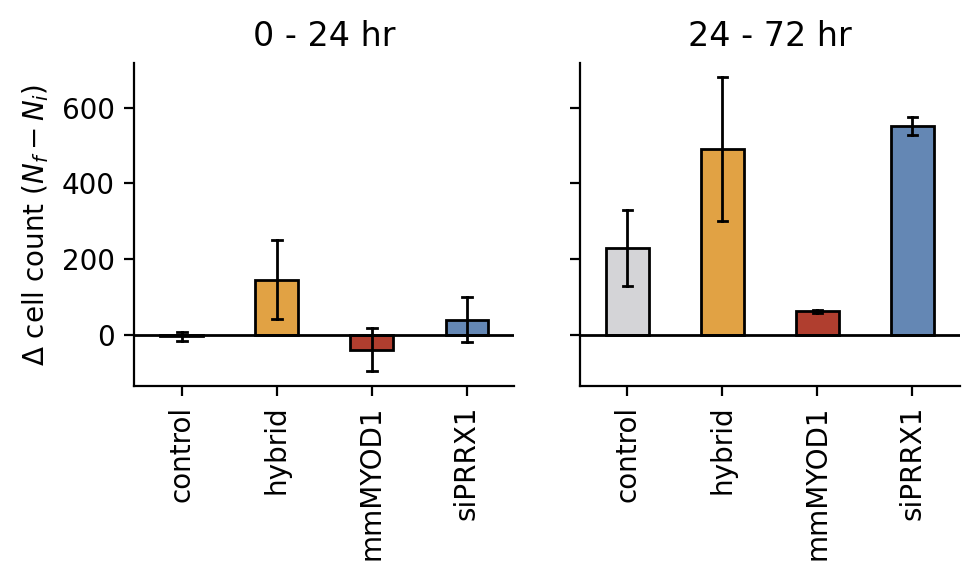

In [32]:
# compute net change in counts
endpoints["delta"] = endpoints["final"] - endpoints["initial"]

endpoints.head()

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

stages = sorted(endpoints['stage'].unique())

for i, stage in enumerate(stages):
    ax = axes[i]
    data = endpoints[endpoints["stage"] == stage]

    sns.barplot(
        data=data,
        x="condition",
        y="delta",
        hue="condition",
        width=0.45,
        ec='k',
        errorbar='sd',
        capsize=0.1,
        err_kws={"linewidth": 1, 'color':'k'},
        palette=cond_palette,
        ax=ax,
        legend=False 
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title("0 - 24 hr" if i == 0 else "24 - 72 hr")
    ax.set_xlabel("")
    ax.set_ylabel("Δ cell count ($N_f - N_i$)" if i == 0 else "")
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

plt.tight_layout(w_pad=2)
plt.show()

In [25]:
endpoints

,condition,scene,stage,initial,final,delta
0,control,B2,1,620,631,11
1,control,B2,2,557,799,242
2,control,C2,1,614,606,-8
3,control,C2,2,551,875,324
4,control,D2,1,495,483,-12
5,control,D2,2,432,555,123
6,hybrid,C3,1,615,751,136
7,hybrid,C3,2,645,1270,625
8,hybrid,C4,1,768,1023,255
9,hybrid,C4,2,768,1340,572


In stage 1, Control ~ mmMYOD1, and HYB ~ siPRRX1

In [47]:
df1 = df.copy()

stage1_ctrl_group = ['control', 'mmMYOD1']

# groups into 2 conditions for stage 1, keeps all 4 for stage 2
df1['grouping_col'] = np.where(
    df1['stage'] == 1,
    np.where(
        df1['condition'].isin(stage1_ctrl_group),
        'control',
        'siPRRX1'
    ),
    df1['condition']
)

df1.head()

,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted,grouping_col
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67,siPRRX1
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67,siPRRX1
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67,siPRRX1
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67,siPRRX1
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67,siPRRX1


In [50]:
display(df1[df1['stage'] == 1]['grouping_col'].value_counts())
display(df1[df1['stage'] == 2]['grouping_col'].value_counts())

grouping_col
siPRRX1    321649
control    181078
Name: count, dtype: int64

grouping_col
hybrid     403301
siPRRX1    387066
control    251191
mmMYOD1    140701
Name: count, dtype: int64

In [71]:
counts = (
    df1.groupby(["time", "stage", "grouping_col", "scene"])
      .size()
      .reset_index(name="n_cells")
)

# shift stage 2 times to follow after stage 1
max_time_stage1 = counts.loc[counts["stage"] == 1, "time"].max()
counts["time_shifted"] = counts["time"] + (
    (counts["stage"] == 2) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
counts['time_hours'] = counts['time_shifted'] / 3

# Get baseline counts (time=0) for each group
baseline = (
    counts.loc[counts["time"] == 0, ["stage", "grouping_col", "scene", "n_cells"]]
    .rename(columns={"n_cells": "baseline_cells"})
)

counts = counts.merge(baseline, on=["stage", "grouping_col", "scene"], how="left")

counts['n_cells_rel'] = counts['n_cells'] / counts['baseline_cells']
counts['n_cells_log2'] = np.log2(counts['n_cells_rel'])
counts['n_cells_abs'] = counts['n_cells'] - counts['baseline_cells']

print(counts.shape)
counts.head()

(2040, 11)


,time,stage,grouping_col,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,control,D3,530,0,0.0,530,1.0,0.0,0
4,0,1,control,D4,626,0,0.0,626,1.0,0.0,0


In [52]:
counts[counts['stage'] == 1].groupby('grouping_col')['scene'].nunique()

grouping_col
control    5
siPRRX1    5
Name: scene, dtype: int64

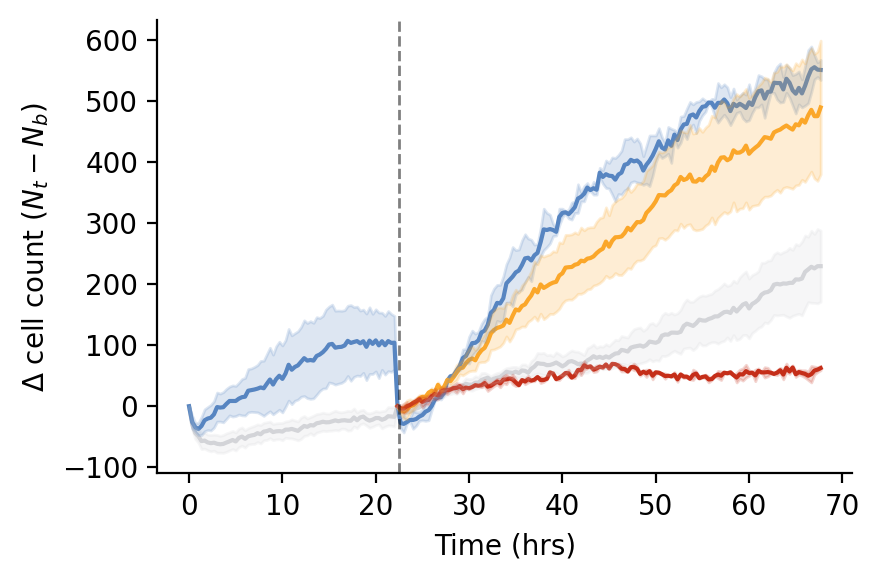

In [81]:
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(4.5, 3))


cond_palette = {
    'control': '#D3D4D8',
    'hybrid': '#FBA72A',
    'mmMYOD1': '#C52E19',
    'siPRRX1': '#5785C1',
}


# summarized lineplot (mean ± 95% CI across scenes)
sns.lineplot(
    data=counts,
    x="time_hours",
    y='n_cells_abs',
    # y="n_cells_log2",
    hue="grouping_col",
    palette=cond_palette,
    lw=1.5,
    errorbar="se",  # mean ± 95% CI
    ax=ax,
    zorder=0,
    legend=False,
)

# stage transition line
plt.axvline(max_time_stage1/3 + 0.5, ls="--", c="k", lw=1, alpha=0.5, zorder=2)

plt.xlabel("Time (hrs)")
# plt.ylabel("Cell count (fold change)")
# plt.ylabel("Cell count")
plt.ylabel("Δ cell count ($N_t - N_b$)")
# plt.ylabel("$log_2$($N_t / N_b$)")

sns.despine()
plt.tight_layout()
plt.show()

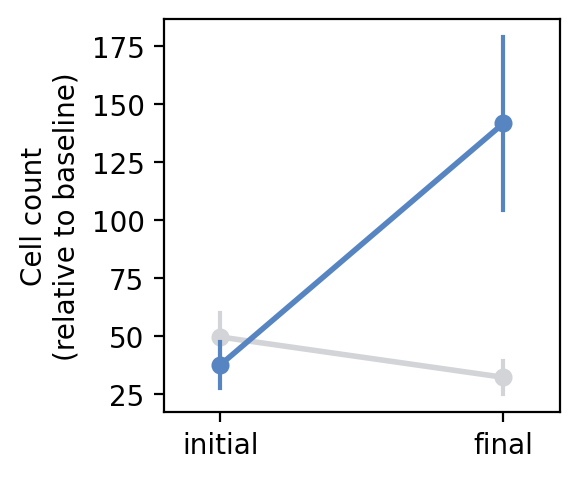

In [70]:
# get global initial and final counts per (condition, scene, stage)
cell_col = 'n_cells_abs'

endpoints = (
    counts.groupby(["grouping_col", "scene", "stage"])
    .agg(initial=(cell_col, "first"), final=(cell_col, "last"))
    .reset_index()
)

endpoints.head()

endpoints_melt = endpoints.melt(
    id_vars=["grouping_col", "scene", "stage"],
    value_vars=["initial", "final"],
    var_name="timepoint", value_name=cell_col
)

endpoints_melt.head()

stage = 1
endpoints_melt = endpoints_melt[endpoints_melt['stage'] == stage]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (3, 2.5)

# plot points
sns.pointplot(
    data=endpoints_melt,
    x="timepoint",
    y=cell_col,
    hue="grouping_col",
    errorbar='se',
    lw=2,
    legend=False,
    palette=cond_palette,
    markersize=5,
    err_kws={"linewidth": 1.5},#, 'color': 'k'}
)

plt.margins(x=0.2)
plt.xlabel("")
plt.ylabel("Cell count\n(relative to baseline)")
plt.tight_layout()
plt.show()

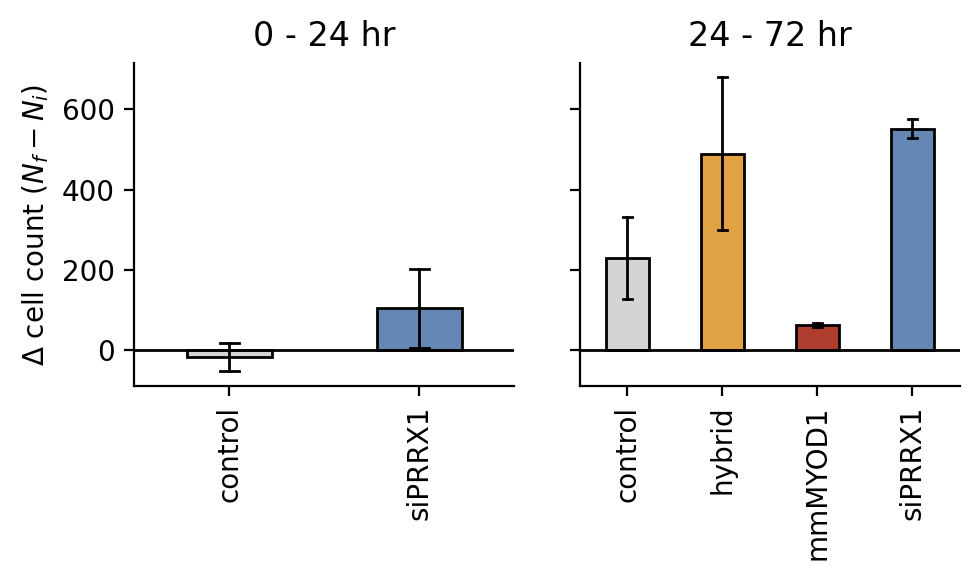

In [83]:
# compute net change in counts
endpoints["delta"] = endpoints["final"] - endpoints["initial"]

endpoints.head()

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

stages = sorted(endpoints['stage'].unique())

for i, stage in enumerate(stages):
    ax = axes[i]
    data = endpoints[endpoints["stage"] == stage]

    sns.barplot(
        data=data,
        x="grouping_col",
        y="delta",
        hue="grouping_col",
        width=0.45,
        ec='k',
        errorbar='sd',
        capsize=0.1,
        err_kws={"linewidth": 1, 'color':'k'},
        palette=cond_palette,
        ax=ax,
        legend=False 
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title("0 - 24 hr" if i == 0 else "24 - 72 hr")
    ax.set_xlabel("")
    ax.set_ylabel("Δ cell count ($N_f - N_i$)" if i == 0 else "")
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

plt.tight_layout(w_pad=2)
plt.show()

In [ ]:
# barplot at several timepoints

# t = [10, 20, 30, 40, 50, 60, 70]

